In [1]:
import sys

In [2]:
# %%capture
try:
    # Attempt to import a module that's only available in Colab
    from google.colab import drive

    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    # Colab specific setup
    drive.mount("/content/drive")
    sys.path.append("/content/drive/MyDrive/structure-loss-classification/")
    my_local_data = "/content/drive/MyDrive/types/"
    %cd '/content/drive/MyDrive/structure-loss-classification/'
    %pip install -r requirements.txt
else:
    # Local machine setup
    my_local_data = "/mnt/g/My Drive/types/"

In [3]:
import torch
import torch.nn as nn

import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision.models.feature_extraction import (
    get_graph_node_names,
    create_feature_extractor,
)

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold

In [5]:
import pytorch_lightning as pl

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pandas as pd

plt.style.use(["science", "notebook", "grid"])

In [7]:
import pickle

In [8]:
from models.models import LeNet5
from lightning_modules.lightning_modules import LitLeNet5
from visualization.filters import display_filters
from visualization.display import process_plot_image
from datasets.data_modules import CustomImageDataModule
from train.train import get_features, train_model
from hyperparameter_tuning.tune import HyperParameterTuner
from datasets.datasets import CustomDatasetWrapper

In [9]:
toTensorAndNormalize = transforms.Compose(
    [
        transforms.Resize((244, 244)),
        # transforms.RandomHorizontalFlip(),
        # transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # mean  # std
    ]
)

In [10]:
from ray import tune

In [11]:
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset

In [12]:
classification_mode="binary"

In [13]:
task = {
    'binary': 2,
    'only_bad': 3,
    'all': 4
}

In [14]:
num_classes = task[classification_mode]

In [15]:
aux_data = CustomDatasetWrapper(
    root_dir=my_local_data,
    classification_mode=classification_mode,
    transform=toTensorAndNormalize,
)

In [16]:
# Try to load cached targets first
try:
    with open(f"logdir/cached_targets_{aux_data.classification_mode}.pkl", "rb") as f:
        targets = pickle.load(f)
except FileNotFoundError:
    targets = [t for _, t in aux_data]
    # Cache the targets for next time
    with open(f"logdir/cached_targets_{aux_data.classification_mode}.pkl", "wb") as f:
        pickle.dump(targets, f)

In [17]:
model = LitLeNet5(num_classes=num_classes, learning_rate=0.001)

In [18]:
trainer_config = {
    "patience": 3,
    "accelerator": "gpu",
    "devices": -1,
    "max_epochs": 5,
    "precision": 32,
    "n_steps": 5,
}

In [19]:
# Assuming aux_data is a dataset object and targets are the labels
train_idx, val_idx, _, _ = train_test_split(
    range(len(aux_data)), targets, test_size=0.2, random_state=42
)

train_data = torch.utils.data.Subset(aux_data, train_idx)
val_data = torch.utils.data.Subset(aux_data, val_idx)

In [20]:
data_module = CustomImageDataModule(
    train_dataset=train_data,
    val_dataset=val_data,
    batch_size=16,
    num_workers=4,
)

### Test train

In [ ]:
val_metrics, cm = train_model(
    model=model,
    trainer_config=trainer_config,
    save_dir="logdir/",
    data_module=data_module,
)

In [22]:
cm

array([[ 0, 12],
       [ 0, 39]])

In [38]:
val_metrics

{'val_loss': 0.41393592953681946,
 'val_accuracy': 0.7647058963775635,
 'val_f1_score': 0.7647058963775635}

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

In [36]:
df = pd.read_csv('logdir/LitLeNet5/lightning_logs/version_0/metrics.csv')

<Axes: xlabel='epoch'>

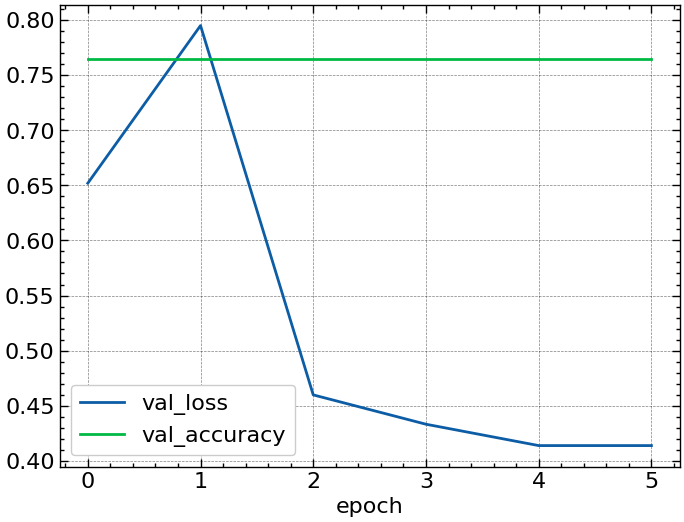

In [41]:
df.plot(kind='line',x='epoch',y=['val_loss', 'val_accuracy'])

In [31]:
aux_data.label_map

{0: 0, 1: 1, 2: 1, 3: 1}

In [30]:
aux_data.dataset.class_to_idx

{'goodIngots': 0, 'typeA': 1, 'typeB': 2, 'typeC': 3}

In [27]:
aux_data.dataset.classes

['goodIngots', 'typeA', 'typeB', 'typeC']

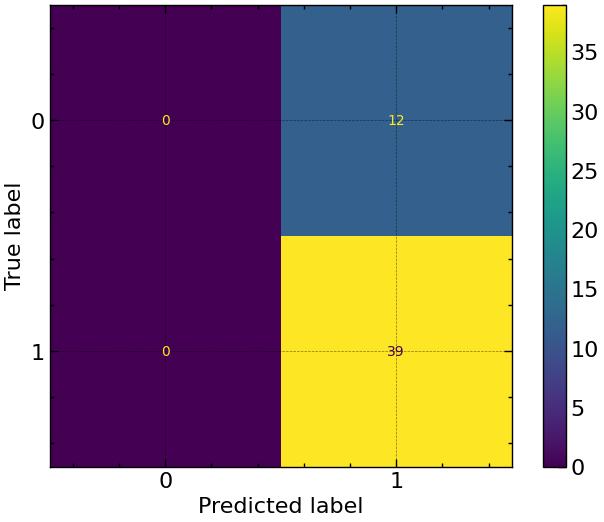

In [32]:
ConfusionMatrixDisplay(np.array(cm)).plot()

## Hyperparameter Tuning

In [ ]:
default_config = {
    "layer_1_size": 128,
    "layer_2_size": 256,
    "lr": 1e-3,
    "batch_size": 16
}

In [ ]:
search_space = {
    "layer_1_size": tune.choice([64, 84, 128]),
    "layer_2_size": tune.choice([16, 32, 64]),
    "lr": tune.loguniform(1e-5, 1e-2),
    "batch_size": tune.choice([16, 32, 64]),
}

In [ ]:
# The maximum training epochs
num_epochs = 10

# Number of sampls from parameter space
num_samples = 10

In [ ]:
tuner = HyperParameterTuner(model=model,
                            datamodule=data_module,
                            search_space=search_space,
                            num_epochs=num_epochs,
                            num_samples=num_samples
                            )

In [ ]:
torch.set_float32_matmul_precision('medium')

In [ ]:
test_config = tuner.hypertune()

In [ ]:
test_config = test_config['train_loop_config']

In [ ]:
test_config 

In [ ]:
tuned_model = LitLeNet5(
                        num_classes = num_classes,
                        learning_rate = test_config['lr'],
                        size_layer_1 = test_config['layer_1_size'],
                        size_layer_2 = test_config['layer_2_size'],
                        )

In [ ]:
tuned_data_module = CustomImageDataModule(
                                        train_dataset=train_data,
                                        val_dataset=val_data,
                                        batch_size=test_config['batch_size'],
                                        num_workers=4,
                                        )

### Re-trained after tuning

In [ ]:
val_metrics = train_model(
    model=tuned_model,
    trainer_config=trainer_config,
    save_dir="logdir/",
    data_module=tuned_data_module,
)